![alt text](https://drive.google.com/uc?export=view&id=1UXScsVx_Wni_JuDdB8LeTnM6jsPfIwkW)

Proprietary content. © Great Learning. All Rights Reserved. Unauthorized use or distribution prohibited.

# Mobile Phone Detection in an Image

## Domain
Mobile Phones, Computer Vision

## Business Context
The ability to process visual information using machine learning algorithms can be very useful. Electronics companies can use it to identify the presence of a mobile in an image (location), mobile brand just by looking at the image, and minor damages if there are any. The computer vision field has multiple applications and based on the available data it can be used to meet business objectives.
Here, we will use a simple convolutional neural network to classify images with and without mobile phones. 
 
## Objective

Given the images and label whether an image has a mobile phone or not, can you train a model that allows you to map and find the presence of mobile phones within the selected images.


### Package version
- tensorflow==2.3.0
- matplotlib==3.2.1
- h5py==2.10.0
- google==2.0.3

## Table of Content

1. Import Libraries

2. Setting options

3. Data loading and Data Analysis 

4. Visualize and Standardize the data

5. Model Building

6. Evaluate Model

7. Conclusion and Interpretation

## 1. Import Libraries

Let us start by mounting the drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Let us check for the version of installed tensorflow.

In [2]:
# used to supress display of warnings
import warnings

# os is used to provide a way of using operating system dependent functionality
# We use it for setting working folder
import os

# Pandas is used for data manipulation and analysis
import pandas as pd 

# Numpy is used for large, multi-dimensional arrays and matrices, along with mathematical operators on these arrays
import numpy as np

# Matplotlib is a data visualization library for 2D plots of arrays, built on NumPy arrays 
# and designed to work with the broader SciPy stack
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import pyplot

# Seaborn is based on matplotlib, which aids in drawing attractive and informative statistical graphics.
import seaborn as sns
import tensorflow 
print(tensorflow.__version__)


#from tensorflow.keras.utils import np_utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD
#from tensorflow.keras.constraints import maxnorm
from PIL import Image
from PIL import ImageMath

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import confusion_matrix

2.5.0


## 2. Setting Options

In [3]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# display all dataframe rows
pd.options.display.max_rows = None

## 3. Data loading and Data Analysis 

### Read images and save the pixel information to an array. Also, save their corresponding label to a list ( YES-Mobile - 1, NO-Mobile - 0). Resize the images to shape (128, 128, 3).

In [4]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/CV with CNN/LAB/mobile-images')
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/CV with CNN/LAB/mobile-images'

In [6]:
import cv2
img=cv2.imread('yes-mobile/img128.png')

In [7]:
# value 3 indicates 3 channels - RGB
img.shape

(90, 90, 3)

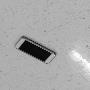

In [8]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [9]:
yes_list=os.listdir('/content/drive/MyDrive/Colab Notebooks/CV with CNN/LAB/mobile-images/yes-mobile')
no_list=os.listdir('/content/drive/MyDrive/Colab Notebooks/CV with CNN/LAB/mobile-images/no-mobile')

In [10]:
yes_images=[]
yes_labels=[]
yes_path='/content/drive/MyDrive/Colab Notebooks/CV with CNN/LAB/mobile-images/yes-mobile'

for i in yes_list:
  #print(i)
  image_path= os.path.join(yes_path, i)
  #image_path
  img=cv2.imread(image_path)
  img=cv2.resize(img, (128,128))
  yes_images.append(img)
  yes_labels.append(1)

In [11]:
len(yes_images)

124

In [12]:
no_images=[]
no_labels=[]
no_path='/content/drive/MyDrive/Colab Notebooks/CV with CNN/LAB/mobile-images/no-mobile'

for i in no_list:
  #print(i)
  image_path= os.path.join(no_path, i)
  #image_path
  img=cv2.imread(image_path)
  img=cv2.resize(img, (128,128))
  no_images.append(img)
  no_labels.append(0)

In [13]:
len(no_images)

121

### Check shape and size of the images

In [14]:
print("Shape of Yes Mobile:", yes_images[0].shape )
print("Shape of No Mobile:", no_images[0].shape )


Shape of Yes Mobile: (128, 128, 3)
Shape of No Mobile: (128, 128, 3)


In [15]:
print("Size of Yes Mobile Images:", len(yes_images) )
print("Size of No Mobile Images:", len(no_images))

Size of Yes Mobile Images: 124
Size of No Mobile Images: 121


In [16]:
print("Size of Yes Mobile Labels:", len(yes_labels) )
print("Size of No Mobile Labels:", len(no_labels))

Size of Yes Mobile Labels: 124
Size of No Mobile Labels: 121


###  What is the percentage of images with and without mobile phone in the data

In [17]:
print("Percentage of images without phone", round((len(no_list) / (len(no_list) + len(yes_list)))*100), "%")
print("Percentage of images with Phone", round((len(yes_list) / (len(no_list) + len(yes_list)))*100), "%")

Percentage of images without phone 49 %
Percentage of images with Phone 51 %


### Concatenate above two arrays (array having image details of with and without mobile) into one variable and check the final size of the data
### Concatenate lists having label data into one list

In [18]:
x_img=np.concatenate((yes_images, no_images), axis=0)

In [19]:
type(x_img)

numpy.ndarray

In [20]:
x_img.shape

(245, 128, 128, 3)

In [21]:
y_lbl=np.concatenate((yes_labels, no_labels), axis=0)

In [22]:
type(y_lbl)

numpy.ndarray

In [23]:
y_lbl.shape

(245,)

In [24]:
y_lbl

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

### Shuffle the above data and labels ( Data and label should be in sync)

In [25]:
from sklearn.utils import shuffle

In [26]:
data,labels=shuffle(x_img,y_lbl, random_state=95)

## 4. Visualize and Standardize the data

### Visualise the first 10 images in the data and print their corresponding labels.

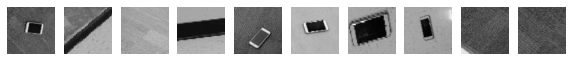

[1 0 0 0 1 1 1 1 0 0]


In [27]:
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(data[i], cmap="gray")
    plt.axis('off')
    #print('label for each of the below image: %s' % (labels[i]))
plt.show()
print(labels[:10])


### Split the data into train and test

In [28]:

Xtrain, Xtest, ytrain, ytest = train_test_split(data, labels, random_state=15) #default split - 30%

### Print shape of the X train and X test data

In [29]:
print("Shape of Xtrain:", Xtrain.shape)
print("Shape of Xtest:", Xtest.shape)
print("Shape of ytrain:", ytrain.shape)
print("Shape of ytest:", ytest.shape)

Shape of Xtrain: (183, 128, 128, 3)
Shape of Xtest: (62, 128, 128, 3)
Shape of ytrain: (183,)
Shape of ytest: (62,)


### Normalize the data by dividing by 255

In [30]:
Xtrain = Xtrain / 255.0
Xtest = Xtest / 255.0

In [31]:
type(Xtrain)

numpy.ndarray

In [32]:
Xtrain[0]

array([[[0.72156863, 0.72156863, 0.72156863],
        [0.73333333, 0.73333333, 0.73333333],
        [0.74509804, 0.74509804, 0.74509804],
        ...,
        [0.76470588, 0.76470588, 0.76470588],
        [0.76862745, 0.76862745, 0.76862745],
        [0.76470588, 0.76470588, 0.76470588]],

       [[0.73333333, 0.73333333, 0.73333333],
        [0.7372549 , 0.7372549 , 0.7372549 ],
        [0.74509804, 0.74509804, 0.74509804],
        ...,
        [0.7372549 , 0.7372549 , 0.7372549 ],
        [0.73333333, 0.73333333, 0.73333333],
        [0.72941176, 0.72941176, 0.72941176]],

       [[0.74901961, 0.74901961, 0.74901961],
        [0.74509804, 0.74509804, 0.74509804],
        [0.74509804, 0.74509804, 0.74509804],
        ...,
        [0.72941176, 0.72941176, 0.72941176],
        [0.72156863, 0.72156863, 0.72156863],
        [0.71764706, 0.71764706, 0.71764706]],

       ...,

       [[0.75686275, 0.75686275, 0.75686275],
        [0.75686275, 0.75686275, 0.75686275],
        [0.75294118, 0

###  One hot encode the labels for train and test data 
Hint:- We need to one hot encode the labels for the model to understand the labels better. We will be using categorical cross entropy as our loss function and for this purpose we need our labels to be in one hot encoded format.

In [33]:
ytest

array([1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1])

In [34]:
ytrain_cat = to_categorical(ytrain)
ytest_cat = to_categorical(ytest)

In [35]:
#Just to check if values are encoded.
ytrain-ytrain_cat[:,1] 

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [36]:
# Here it is 2D array - which helps in reading 1st record belongs to 0 class, 2nd record belongs to 1 class.
ytest_cat[0:10]

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.]], dtype=float32)

In [37]:
print(f'Sample value before one hot encoding {ytrain[52]}\n')
ytrain_cat = tensorflow.keras.utils.to_categorical(ytrain,num_classes=2)
ytest_cat= tensorflow.keras.utils.to_categorical(ytest,num_classes=2)
print(f'Sample value after one hot encoding {ytrain_cat[52]}')

Sample value before one hot encoding 1

Sample value after one hot encoding [0. 1.]


## 5. Model building

### Define the model architecture using TensorFlow with a Conv2D layer followed by dense layers with activation as ReLu and softmax respectively. 

In [52]:
tf.keras.backend.clear_session()
# Create the model 
model = Sequential()

#Layer 1 -conv2D

model.add(Conv2D(filters=32, kernel_size=3, input_shape=(128, 128, 3), activation='relu'))
#model.add(tf.keras.layers.BatchNormalization(center=True, scale=True))
model.add(MaxPooling2D((2,2)))
#model.add(Dropout(0.2))

#Layer 2 - conv2D

model.add(Conv2D(64, (2,2), activation="relu")) #(3,3) = kernel_size=3 , 64 ==> filter_size
#model.add(tf.keras.layers.BatchNormalization(center=True, scale=True))
model.add(MaxPooling2D((2,2)))


#Flatten
model.add(Flatten())

#Dense Layer 

model.add(Dense(64, kernel_initializer='he_normal', activation="linear"))
#model.add(tf.keras.layers.BatchNormalization(center=True, scale=True))
#model.add(Dropout(0.2))

model.add(Dense(32, kernel_initializer='he_normal',activation="relu"))
#model.add(tf.keras.layers.BatchNormalization(center=True, scale=True))
#model.add(Dropout(0.2))

model.add(Dense(2, activation="softmax"))

model.summary()
    


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 126, 126, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 63, 63, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 62, 62, 64)        8256      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 31, 31, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 61504)             0         
_________________________________________________________________
dense (Dense)                (None, 64)                3936320   
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2

### Compile the above model using appropriate loss metric. Try with sgd, adam optimizer and "accuracy" as metrics. 

In [53]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

### Fit the model on the training dataset along with it's equivalent one hot encoded labels

In [54]:
model_checkpoint = ModelCheckpoint('Mobile_Data.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1, save_freq='epoch')

callback= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

training_history = model.fit(Xtrain, ytrain_cat,
                    validation_data= (Xtest, ytest_cat),
                    batch_size=32, epochs = 100, 
                    verbose = 1,
                    callbacks=[callback,model_checkpoint])

Epoch 1/100
6/6 [==============================] - 1s 52ms/step - loss: 3.3751 - accuracy: 0.4973 - val_loss: 2.3795 - val_accuracy: 0.5484

Epoch 00001: val_accuracy improved from -inf to 0.54839, saving model to Mobile_Data.h5
Epoch 2/100
6/6 [==============================] - 0s 24ms/step - loss: 1.3785 - accuracy: 0.4809 - val_loss: 0.5156 - val_accuracy: 0.6613

Epoch 00002: val_accuracy improved from 0.54839 to 0.66129, saving model to Mobile_Data.h5
Epoch 3/100
6/6 [==============================] - 0s 23ms/step - loss: 0.4086 - accuracy: 0.8306 - val_loss: 0.3631 - val_accuracy: 0.8226

Epoch 00003: val_accuracy improved from 0.66129 to 0.82258, saving model to Mobile_Data.h5
Epoch 4/100
6/6 [==============================] - 0s 26ms/step - loss: 0.2927 - accuracy: 0.8798 - val_loss: 0.3635 - val_accuracy: 0.8387

Epoch 00004: val_accuracy improved from 0.82258 to 0.83871, saving model to Mobile_Data.h5
Epoch 5/100
6/6 [==============================] - 0s 24ms/step - loss: 0.2

## 6. Evaluate the model


### Evaluate the model on test data and print loss and accuracy

In [55]:
print('Training score:', model.evaluate(Xtrain, ytrain_cat, batch_size=32))
print('Testing score:',model.evaluate(Xtest, ytest_cat, batch_size=32))

6/6 [==============================] - 0s 7ms/step - loss: 0.1640 - accuracy: 0.9344
Training score: [0.16402901709079742, 0.9344262480735779]
2/2 [==============================] - 0s 10ms/step - loss: 0.2821 - accuracy: 0.9355
Testing score: [0.2821424901485443, 0.9354838728904724]


### Predict label data of the test data and check confusion matrix

In [56]:
test_pred = np.argmax(model.predict(Xtest), axis=1)  # index of max value
test_pred

array([1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1])

In [57]:
confusion_matrix(ytest, test_pred)

array([[33,  1],
       [ 3, 25]])

### Display test images and their predicted label for a few samples

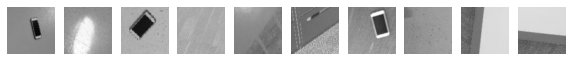

[1 0 1 0 0 0 1 0 0 0]


In [58]:
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(Xtest[i], cmap="gray")
    plt.axis('off')
    #print('label for each of the below image: %s' % (labels[i]))
plt.show()
print(test_pred[:10])


### Print following plots
1. Plot training accuracy vs validation accuracy
2. Plot training loss vs validation loss

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


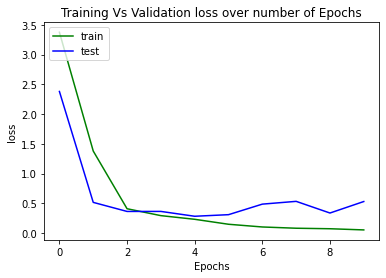

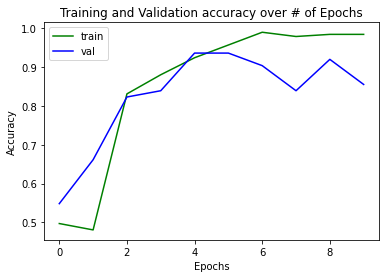

In [59]:
# list all data in history
print(training_history.history.keys())

# summarize history for loss
plt.plot(training_history.history['loss'],'g', label='Training loss' )
plt.plot(training_history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(training_history.history['accuracy'], 'g', label='Training accuracy')
plt.plot(training_history.history['val_accuracy'], 'b', label='validation accuracy')
plt.title('Training and Validation accuracy over # of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [47]:
# acc = training_history.history['accuracy']
# loss = training_history.history['loss']

# val_acc = training_history.history['val_accuracy']
# val_loss = training_history.history['val_loss']

# epochs = range(len(acc))
# plt.plot(epochs,acc)
# plt.plot(epochs,val_acc)
# plt.plot(epochs,loss)
# plt.plot(epochs,val_loss)


## 7.  Conclusion and Interpretation

### Write your observations and findings

From the above graphs, my observation and findings are:
  1. The training accuracy (green color) increases significantly after 1 epoch and it gradually increases after 2 epochs. After 6 epochs, the accuracy becomes stagnant.
  2. The Validation accuracy (blue color) gradually increases from 0 eepoch to 2 epochs and keeps fluctuating and reduces. The maximum accuracy is captured on epoch# 6.
  3. As the number of epochs increases, the validation and training loss decreases significantly. There is fluctuation in the validation loss in between and becomes stagnant at the end.

  This is the basic model built with convol2D layers and dense layers.
  Here I have started with initialising the model by specifying that the model is a sequential model. After initialising the model I add

  1 x convolution layer of 32 channel of 3x3 kernal.
  1 x maxpool layer of 2x2 pool size
  1 x convolution layer of 64 channel of 3x3 kernal.
  1 x maxpool layer of 2x2 pool size

  After creating all the convolution I pass the data to the dense layer so for that I flatten the vector which comes out of the convolutions and add

 1 x Dense layer of 64 units
 1 x Dense Layer of 32 units
 1 x Dense Layer of 2 units - Final layer units will match to the # of classes.

 I used Linear, RELU activation in the 1st 2 dense layer of 64 and 32 units respectively so that I stop forwarding negative values through the network.
 I use a 2 unit dense layer in the end with softmax activation as I have 2 classes to predict from in the end which are Mobile or No-Mobile. The softmax layer will output the value between 0 and 1 based on the confidence of the model that which class the images belongs to.

## 8. Further Explore

### Try changing a few hyperparameters such as number of layers in the network or number of units in a hidden layer or try different activation functions in the hidden layers and see if you get better results than the previous network

In [47]:
Lab Instructor confirmed that this question is optional and we can try out more options as time permitted. I am exploring more options in my assessment on CV with CNN and hence I am leaving it as optional here.